In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import MinMaxScaler

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense,Dropout
from keras.optimizers import Adam

In [4]:
df = pd.read_csv('c:\\Users\\DELL\\OneDrive\\Desktop\\Documents\\dataaaa\\AAPL_featuress.csv',parse_dates=['date'])

In [5]:
#Loaded last year's stock data for Apple Inc. (AAPL) from Yahoo Finance, including features like Open, High, Low, Close, Volume.
from datetime import datetime, timedelta
end_date = datetime.now()
start_date = end_date - timedelta(days=365) # Simple one-year calculation

# Filter the DataFrame using boolean conditions
# The '&' operator combines conditions (use parentheses for clarity)
df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

In [14]:
import os
import pandas as pd
import time

file_path = "dataaaa/AAPL_featuress.csv"

# 1. Force close/delete to break any locks
if os.path.exists(file_path):
    os.remove(file_path)
    time.sleep(1) # Brief pause for OneDrive/Windows to catch up

# 2. Save the fresh data
df.to_csv(file_path, index=False)
print(f"Verified Write: {os.path.getsize(file_path)} bytes saved.")

Verified Write: 23933 bytes saved.


In [6]:
df.head()

,date,open,high,low,close,volume
6,2025-03-18 13:30:00,214.160004,215.149994,211.490005,212.690002,42432400
7,2025-03-19 13:30:00,214.220001,218.759995,213.750000,215.240005,54385400
8,2025-03-20 13:30:00,213.990005,217.490005,212.220001,214.100006,48862900
9,2025-03-21 13:30:00,211.559998,218.839996,211.279999,218.270004,94127800
10,2025-03-24 13:30:00,221.000000,221.479996,218.580002,220.729996,44299500


In [8]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[['close']])

In [9]:
split_idx = (0.8*(int(len(df))))
train_data = scaled_data[:int(split_idx)]
test_data = scaled_data[int(split_idx):]

In [10]:
test_data

array([[0.92827632],
       [0.93047373],
       [0.89382072],
       [0.89821555],
       [0.87386828],
       [0.87694472],
       [0.88995352],
       [0.86622132],
       [0.87843881],
       [0.89118393],
       [0.88758013],
       [0.89074455],
       [0.88476738],
       [0.87404398],
       [0.86657298],
       [0.83361174],
       [0.79054218],
       [0.77269917],
       [0.7613607 ],
       [0.76426117],
       [0.77199612],
       [0.77902774],
       [0.76944704],
       [0.75406513],
       [0.7305089 ],
       [0.65289616],
       [0.66124631],
       [0.66739918],
       [0.66467428],
       [0.72945418],
       [0.75459249],
       [0.73850752],
       [0.75468047],
       [0.76522818],
       [0.85778332],
       [0.85312481],
       [0.91474016],
       [0.90964227],
       [0.92906736],
       [0.89830353],
       [0.89004123],
       [0.90603848],
       [0.78500492],
       [0.73270632],
       [0.80390264],
       [0.80803379],
       [0.77489659]])

In [11]:
train_data.shape,test_data.shape

((186, 1), (47, 1))

In [12]:
def create_sequences(data,n_steps):
    X, y = [],[]
    for i in range(len(data)-n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])
    return np.array(X),np.array(y)

In [13]:
n_steps = 30
X_train,y_train = create_sequences(train_data,n_steps)
X_test,y_test = create_sequences(test_data,n_steps)

In [14]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((156, 30, 1), (156, 1), (17, 30, 1), (17, 1))

In [15]:
tf.keras.backend.set_floatx('float32')  # CPU = float32 like GPU
X_train = X_train.astype(np.float32)
y_train = y_train.astype(np.float32)

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization,Activation, LayerNormalization
from keras.optimizers import Adam

In [34]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=20,             # Wait 5 epochs for improvement
    restore_best_weights=True  # Automatically reverts to best weights
)


model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(30, 1)),  # Tomorrow only!
    Dropout(0.1),
    Dense(32),
    LayerNormalization(),
    Activation('relu'),
    Dropout(0.1),
    Dense(1) # Single price!
])

# Volatility-aware optimizer
opt= Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-07,clipnorm =1.0)
model.compile(optimizer=opt, loss='mse')
model.fit(X_train,y_train,validation_data=(X_test,y_test),callbacks = [early_stop],epochs=100, verbose=1)

Epoch 1/100


c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - loss: 0.6166 - val_loss: 0.3119
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.2074 - val_loss: 0.0475
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1076 - val_loss: 0.1374
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0769 - val_loss: 0.0029
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0636 - val_loss: 0.0092
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0511 - val_loss: 0.0185
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0241 - val_loss: 0.0028
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0221 - val_loss: 0.0096
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0185 - val_loss: 0.0032
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0178 - val_loss: 0.0031
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0142 - val_loss: 0.0075
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0165 - val_loss: 0.0031


In [15]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,029 (222.77 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,020 (148.52 KB)

In [35]:
n_steps = 30 
n_future = 30
current_input = df['close'].tail(n_steps).values 
current_input = scaler.transform(current_input.reshape(-1,1)) 
predictions = [] 
for i in range(n_future): 
    X = current_input.reshape(1, n_steps, 1) 
    yhat = model.predict(X, verbose=0) 
    predictions.append(yhat[0,0]) 
    current_input = np.append(current_input[1:], yhat) 
predictions_real = scaler.inverse_transform( np.array(predictions).reshape(-1,1) )

c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [36]:
print(predictions_real)

[[266.43796]
 [267.29333]
 [267.95477]
 [268.49454]
 [268.92737]
 [269.26776]
 [269.5209 ]
 [269.6908 ]
 [269.805  ]
 [269.8794 ]
 [269.92206]
 [269.9423 ]
 [269.9477 ]
 [269.94147]
 [269.92917]
 [269.91565]
 [269.90176]
 [269.88913]
 [269.87524]
 [269.86398]
 [269.85303]
 [269.8446 ]
 [269.8377 ]
 [269.83395]
 [269.83228]
 [269.83133]
 [269.83615]
 [269.84406]
 [269.8498 ]
 [269.85535]]


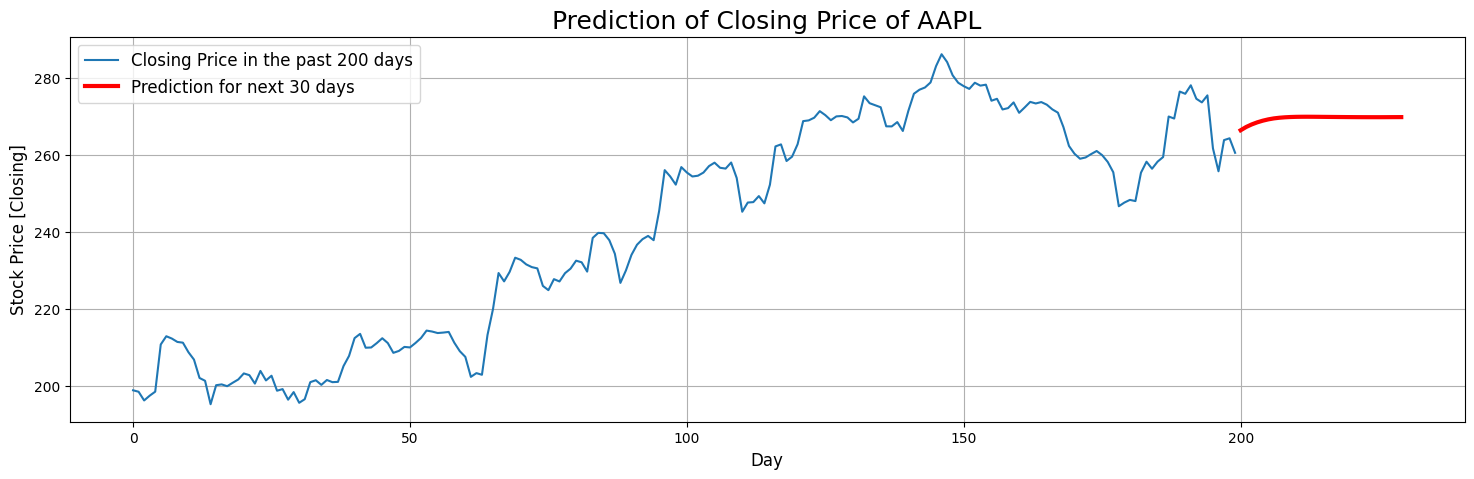

In [37]:
days=np.arange(0,200)
day_pred=np.arange(200,230)
plt.figure(figsize=(18,5))
plt.plot(days,df['close'].tail(200), label = 'Closing Price in the past 200 days')
plt.plot(day_pred,predictions_real, color = 'red', label = 'Prediction for next 30 days', lw = 3)
plt.legend(fontsize = 12)
plt.title('Prediction of Closing Price of AAPL', fontsize = 18)
plt.xlabel('Day' ,fontsize = 12)
plt.ylabel('Stock Price [Closing]' ,fontsize = 12)
plt.grid()
plt.show()

In [38]:
y_pred = model.predict(X_test)

# Inverse transform (only Close column matters for eval)

y_test_full = y_test
y_pred_full = y_pred.flatten()
y_test_full = y_test_full.reshape(-1, 1)
y_pred_full = y_pred_full.reshape(-1, 1)

y_test_inv = scaler.inverse_transform(y_test_full)
y_pred_inv = scaler.inverse_transform(y_pred_full)

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
RMSE: 6.01, MAE: 5.14
